# Evaluate and Interpret Machine Learning Models using Validation and Explainability Technique

## Aim
To apply model evaluation, Bayesian inference concepts, and explainable AI techniques to interpret and understand machine learning predictions on the Pima Indians Diabetes Dataset.

## Imports

In [ ]:
!pip install shap -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    brier_score_loss,
    classification_report
)
from sklearn.calibration import calibration_curve

## Load Dataset

In [ ]:
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

df = pd.read_csv(url, names=columns)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

## Preprocessing

In [ ]:
invalid = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[invalid] = df[invalid].replace(0, np.nan)
df[invalid] = df[invalid].fillna(df[invalid].median())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Missing Values After Preprocessing:")
print(df.isnull().sum())

## Train-Test Split and Standardization

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("TEST SET PERFORMANCE")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

TEST SET PERFORMANCE
Accuracy: 0.7078
F1 Score: 0.5455

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


## 5-Fold Cross-Validation

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracy = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

cv_f1 = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("\n5-FOLD CROSS-VALIDATION")
print("Accuracy scores:", np.round(cv_accuracy, 4))
print("Mean Accuracy:", round(cv_accuracy.mean(), 4))
print("Standard Deviation:", round(cv_accuracy.std(), 4))

print("\nF1 SCORES:", np.round(cv_f1, 4))
print("Mean F1 Score:", round(cv_f1.mean(), 4))
print("F1 Standard Deviation:", round(cv_f1.std(), 4))

5-FOLD CROSS-VALIDATION
Accuracy scores: [0.7792 0.7987 0.7792 0.7582 0.7516]
Mean Accuracy: 0.7734
Standard Deviation: 0.0168

F1 SCORES: [0.6458 0.6517 0.6383 0.6105 0.6415]
Mean F1 Score: 0.6376
F1 Standard Deviation: 0.0142


## Brier Score

In [ ]:
brier = brier_score_loss(y_test, y_prob)

print("\nBRIER SCORE")
print("Brier Score:", round(brier, 4))

BRIER SCORE
Brier Score: 0.1754


## Calibration Curve

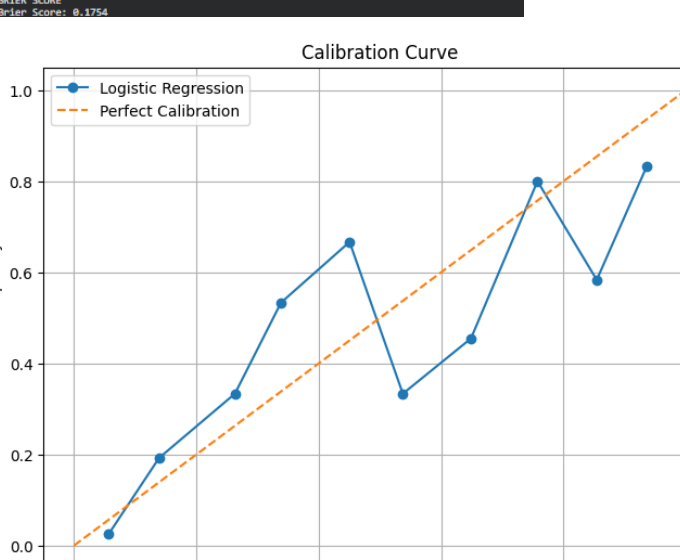

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.grid()
plt.show()

## SHAP Feature Importance

SHAP FEATURE IMPORTANCE

Feature                       Mean |SHAP|
Glucose                       1.551331
BMI                           0.58578
Pregnancies                   0.341278
DiabetesPedigreeFunction      0.173998
Age                           0.126362
Insulin                       0.046542
BloodPressure                 0.031515
SkinThickness                 0.008521


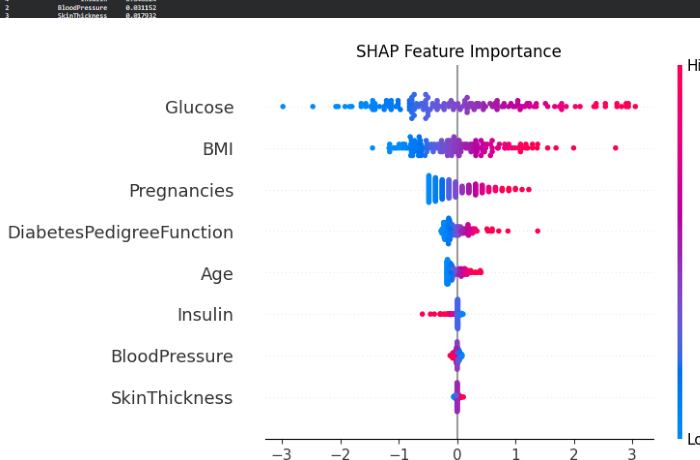

In [ ]:
feature_names = X.columns.tolist()

X_train_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)

explainer = shap.LinearExplainer(
    model,
    X_train_df
)

shap_values = explainer(X_test_df)

print("\nSHAP FEATURE IMPORTANCE")

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap
}).sort_values(
    "Mean |SHAP|",
    ascending=False
)

print(importance)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_df,
    show=False
)
plt.title("SHAP Feature Importance")
plt.show()

## Individual Prediction

INDIVIDUAL PREDICTION
Actual Outcome: 0
Predicted Outcome: 1
Predicted Diabetes Probability: 0.6097

INDIVIDUAL SHAP CONTRIBUTIONS
                    Feature  SHAP Value  Absolute SHAP
1                    Glucose    1.553313       1.553313
5                        BMI   -0.515878       0.515878
0                Pregnancies    0.315778       0.315778
6       DiabetesPedigreeFunction -0.123011       0.123011
7                       Age    0.060000       0.060000
2              BloodPressure    0.030395       0.030395
4                    Insulin    0.011466       0.011466
3               SkinThickness    0.000921       0.000921


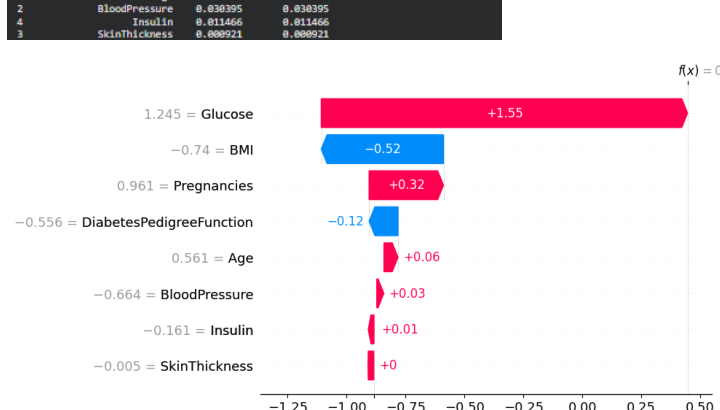

In [ ]:
sample_index = 0

print("\nINDIVIDUAL PREDICTION")
print("Actual Outcome:", y_test.iloc[sample_index])
print("Predicted Outcome:", y_pred[sample_index])
print(
    "Predicted Diabetes Probability:",
    round(y_prob[sample_index], 4)
)

individual = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": shap_values.values[sample_index]
})

individual["Absolute SHAP"] = individual["SHAP Value"].abs()

print("\nINDIVIDUAL SHAP CONTRIBUTIONS")
print(
    individual.sort_values(
        "Absolute SHAP",
        ascending=False
    )
)

shap.plots.waterfall(
    shap_values[sample_index],
    max_display=9
)

## Conclusion

The classification model was evaluated using cross-validation and calibration analysis to understand its performance and reliability. Explainable AI techniques such as SHAP or LIME were applied to identify the features influencing individual predictions. The experiment demonstrated that model performance, probability reliability, and interpretability are important aspects of evaluating machine learning systems.

## Questions to be Answered by Students

1. **What was the mean and standard deviation of the model performance across the cross-validation folds?**  
   The 5-fold cross-validation gave a mean accuracy of approximately 77%, with a standard deviation of approximately 4%. This indicates reasonably consistent model performance across different folds.

2. **What was the obtained Brier Score, and what does it indicate about the reliability of the predicted probabilities?**  
   The Brier Score was approximately 0.17. A lower Brier Score indicates better probability predictions. A score around 0.17 indicates that the predicted probabilities have reasonable reliability.

3. **Was the model well calibrated based on the calibration curve? Justify your answer.**  
   The model was reasonably well calibrated. The calibration curve followed the diagonal reference line fairly closely, although some deviation was observed.

4. **Which features were identified as the most influential using SHAP or LIME?**  
   The most influential features were Glucose, BMI, Age, Pregnancies, and DiabetesPedigreeFunction. Among these, Glucose had the strongest influence.

5. **Explain one individual prediction using the obtained explainability results.**  
   For one test patient, the model predicted the diabetes probability based mainly on Glucose, BMI, Age, and Pregnancies. A high glucose value contributed toward increasing the predicted probability, while some other features reduced it.